In [11]:
# Импорты
import matplotlib.pyplot as plt
import numpy as np
import cv2
import skimage
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from skimage.metrics import structural_similarity as ssim

RS = 42

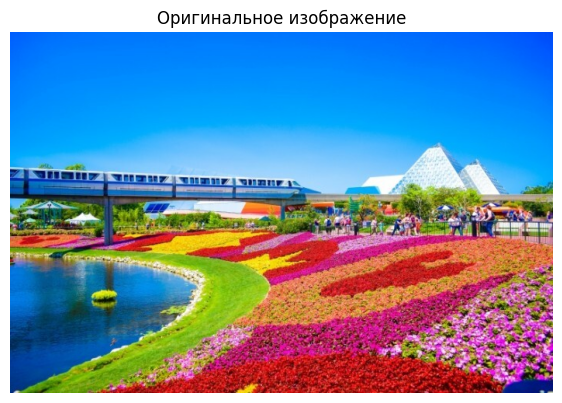

In [12]:
# Функция для вывода изображения
def draw_picture(image, title, bgr=True):
    if bgr:
        b, g, r = cv2.split(image)
        image = cv2.merge([r, g, b])

    plt.figure(figsize=(7, 5))
    plt.axis('off')
    plt.imshow(image)
    plt.title(title)
    plt.show()

img = cv2.imread('feml.jpg')
draw_picture(img, 'Оригинальное изображение', bgr=True)

In [13]:
# Функция для вывода метрики SSIM
def ssim_metrics(original_image, segmented_image):
    original_gray = cv2.cvtColor(original_image, cv2.COLOR_RGB2GRAY)
    segmented_gray = cv2.cvtColor(segmented_image.astype('uint8'), cv2.COLOR_RGB2GRAY)

    similarity_index = ssim(original_gray, segmented_gray, data_range=segmented_gray.max() - segmented_gray.min())

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.axis('off')
    plt.imshow(original_image)
    plt.title('Оригинальное изображение')

    plt.subplot(1, 2, 2)
    plt.axis('off')
    plt.imshow(segmented_image)
    plt.title(f'SSIM: {similarity_index:.2f})')
    plt.show()
    return

In [14]:
# Разбивка изображения на пиксели
pixel_data = img.reshape((-1, 3))
print(pixel_data)

[[255  92   0]
 [255  92   0]
 [253  93   0]
 ...
 [189 213 203]
 [187 212 202]
 [182 208 195]]


KMeans и метрика SSIM
Сегментировано кластеров: 2


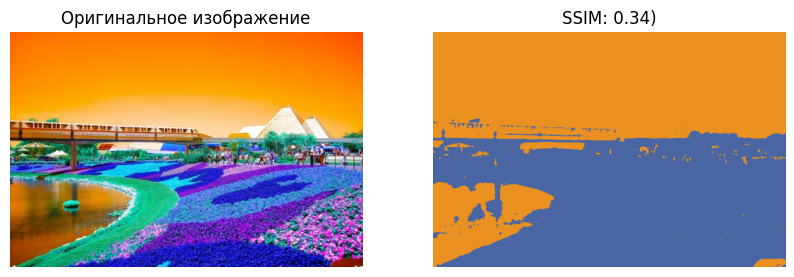

Сегментировано кластеров: 5


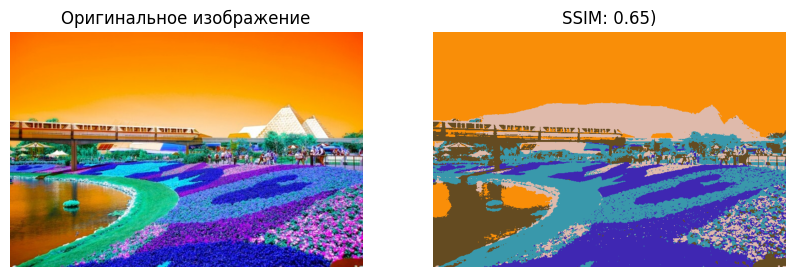

Сегментировано кластеров: 10


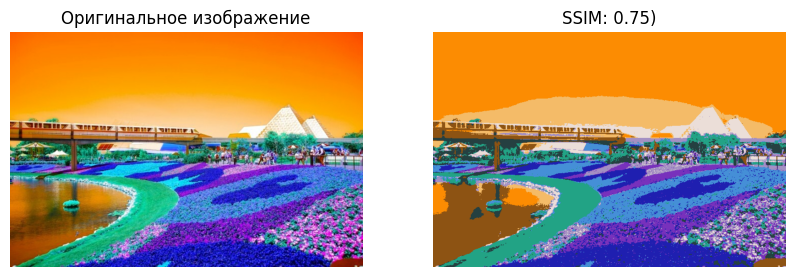

Сегментировано кластеров: 20


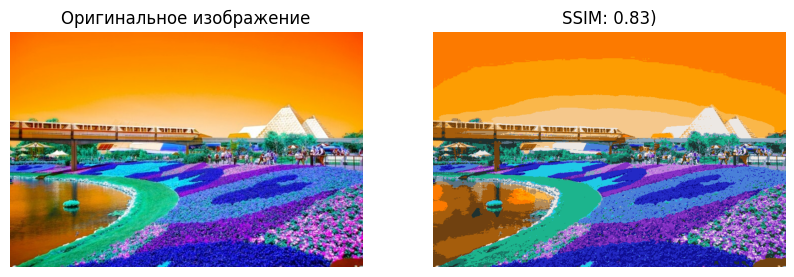

In [15]:
# KMeans и метрика SSIM

print("KMeans и метрика SSIM")
for count_clusters in [2, 5, 10, 20]:
    print(f'Сегментировано кластеров: {count_clusters}')
    kmeans = KMeans(n_clusters=count_clusters, random_state=RS, n_init='auto')
    kmeans.fit(pixel_data)
    labels = kmeans.labels_
    centers = kmeans.cluster_centers_

    segmented_image_rgb = centers[labels].reshape(img.shape).astype(int)

    ssim_metrics(img, segmented_image_rgb)

Кластеризация с помощью DBSCAN


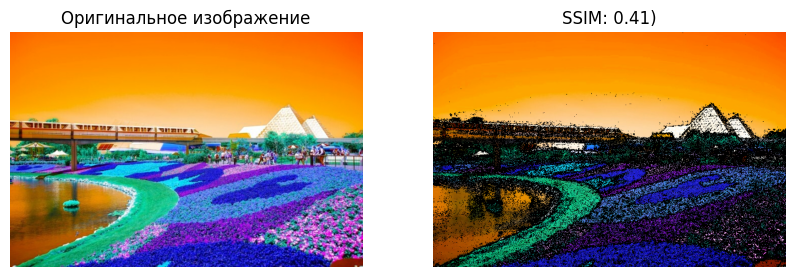

In [16]:
# DBSCAN и метрика SSIM
dbscan_model = DBSCAN(eps=1, min_samples=2)
dbscan_model.fit(pixel_data)

labels = dbscan_model.labels_
unique_labels = set(labels)

segmented_image_rgb = np.zeros_like(pixel_data, dtype=np.uint8)

for label in unique_labels:
    if label == -1:
        continue

    cluster_points_indices = np.where(labels == label)
    cluster_color = pixel_data[cluster_points_indices].mean(axis=0)
    segmented_image_rgb[cluster_points_indices] = cluster_color.astype(np.uint8)

segmented_image_rgb = segmented_image_rgb.reshape(img.shape)
print('Кластеризация с помощью DBSCAN')
ssim_metrics(img, segmented_image_rgb)


AgglomerativeClustering и метрика SSIM
Масштабирование изображения до 50x50 для уменьшения потребления памяти.
Сегментировано кластеров: 2


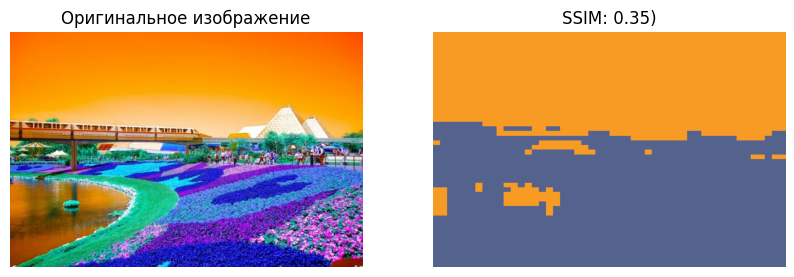

Сегментировано кластеров: 5


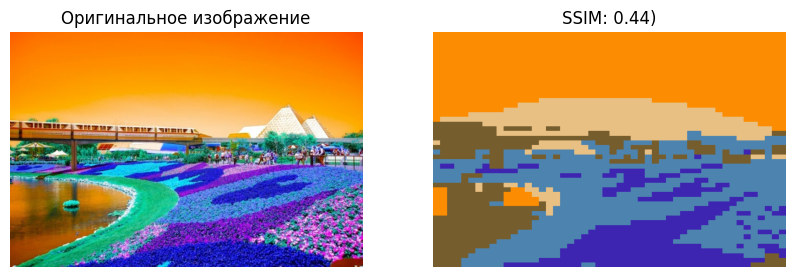

Сегментировано кластеров: 10


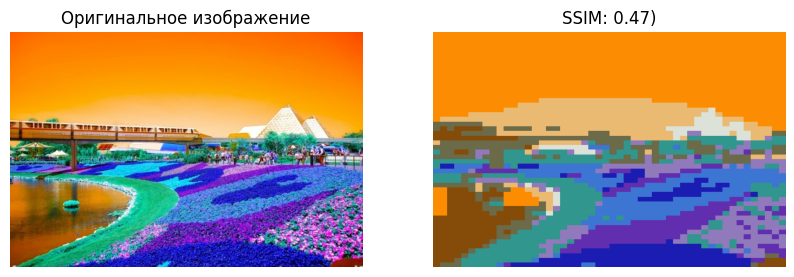

Сегментировано кластеров: 20


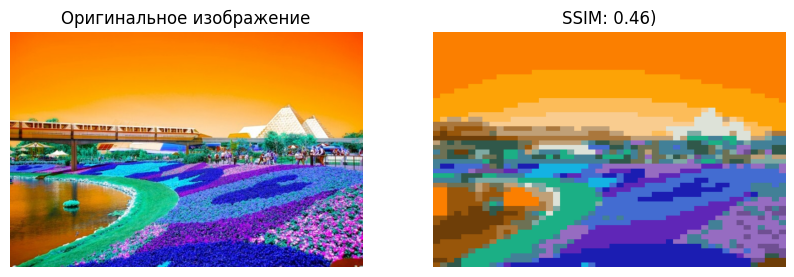

In [17]:
# AgglomerativeClustering и метрика SSIM
import cv2
import numpy as np
from sklearn.cluster import AgglomerativeClustering

print("AgglomerativeClustering и метрика SSIM")

# Resize the image to reduce memory usage
new_width = 50
new_height = 50
print(f"Масштабирование изображения до {new_width}x{new_height} для уменьшения потребления памяти.")
resized_img = cv2.resize(img, (new_width, new_height), interpolation=cv2.INTER_AREA)
pixel_data_resized = resized_img.reshape((-1, 3))

for count_clusters in [2, 5, 10, 20]:
    print(f'Сегментировано кластеров: {count_clusters}')
    agg_clustering = AgglomerativeClustering(n_clusters=count_clusters)
    labels = agg_clustering.fit_predict(pixel_data_resized)
    centers = np.array([pixel_data_resized[labels == i].mean(axis=0) for i in range(count_clusters)])

    segmented_image_rgb_resized = centers[labels].reshape(resized_img.shape).astype(np.uint8)

    # Resize the segmented image back to original dimensions for SSIM calculation
    segmented_image_original_size = cv2.resize(segmented_image_rgb_resized, (img.shape[1], img.shape[0]), interpolation=cv2.INTER_NEAREST)

    ssim_metrics(img, segmented_image_original_size)

### Результаты:

*   **KMeans:**
    *   **K=2:** SSIM = 0.34
    *   **K=5:** SSIM = 0.65
    *   **K=10:** SSIM = 0.75
    *   **K=20:** SSIM = 0.83

*   **DBSCAN:**
    *   SSIM = 0.41 (для параметров `eps=1`, `min_samples=2`)

*   **AgglomerativeClustering (на масштабированном до 50x50 изображении):**
    *   **K=2:** SSIM = 0.35
    *   **K=5:** SSIM = 0.44
    *   **K=10:** SSIM = 0.47
    *   **K=20:** SSIM = 0.46

### a) Какая модель показала лучший результат?

**Наилучший результат показала модель KMeans с K=20, достигнув SSIM = 0.83.**

### Общие выводы:

1.  **KMeans** продемонстрировал самую высокую производительность с точки зрения метрики SSIM, особенно при увеличении количества кластеров (K). Это значит, что KMeans эффективно выделяет основные цветовые регионы, которые хорошо коррелируют с оригинальной структурой изображения. Кроме того при дальнейшем увеличении количества кластеров метрика SSIM продолжает расти и при количестве кластеров 1000 равна 0,98, При это время на обучение модели значительнно вырастает.
2.  **DBSCAN** показал самый низкий результат (SSIM = 0.41). Этот метод чувствителен к выбору параметров `eps` и `min_samples`, и его производительность может значительно меняться в зависимости от них.
3.  **AgglomerativeClustering** Здесь метрика SSIM также растет с увеличением количества кластеров, хотя и не так как KMeans. Важно отметить, что `AgglomerativeClustering` потребляет много памяти, что привело к тому что обучение модели приходится выполнять на значительно уменьшенной версии изображения (50x50 пикселей). Это уменьшение разрешения, вероятно, существенно повлияло на метрику SSIM, так как детали изображения были потеряны. Следовательно, прямое сравнение с KMeans, который работал с оригинальным разрешением, не совсем корректно. Даже при увеличении K, SSIM для `AgglomerativeClustering` не показал значительного улучшения.

**Итого:** Если нет строгих ограничений по вычислительным ресурсам и требуется высокое качество сегментации, **KMeans** является наиболее подходящим методом из протестированных.